# EDA — Desempenho, engajamento e efetividade do programa

Bloco A do storytelling (`docs/fontes/enunciado-datathon.md`): perguntas 2, 3,
7, 8 e 10. A 9 (modelo preditivo de defasagem) está em
`notebooks/01_modelagem.ipynb` — não mexida aqui.

Fonte: `data/processed/panel_longitudinal.csv` (painel completo, 2022-2024) e
`data/processed/features.csv` (deltas ano a ano, ver `src/tc5/features.py`).
Decisões de consolidação em `docs/decisions/0001-consolidacao-painel.md`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

panel = pd.read_csv("../data/processed/panel_longitudinal.csv")
feats = pd.read_csv("../data/processed/features.csv")

# pedra vem com grafia inconsistente entre anos (Agata/Ágata) e um placeholder
# de registro pendente em 2024 (INCLUIR) — ver docs/decisions/0001.
panel["pedra_norm"] = panel["pedra"].replace({"Agata": "Ágata"})
panel.loc[panel["pedra_norm"] == "INCLUIR", "pedra_norm"] = np.nan
PEDRA_ORDEM = ["Quartzo", "Ágata", "Ametista", "Topázio"]

print(f"painel: {len(panel)} linhas | features: {len(feats)} linhas")

painel: 3030 linhas | features: 1874 linhas


## Q2 — O IDA está melhorando, estagnado ou caindo?

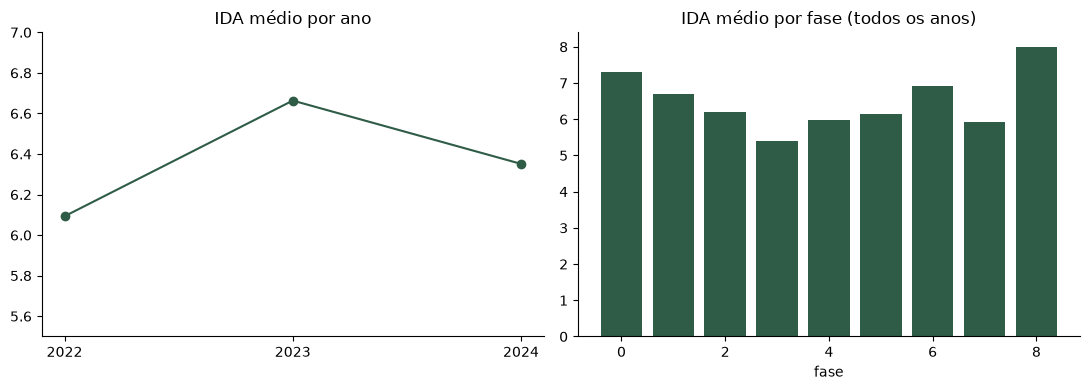

          mean  count
ano                  
2022  6.092907    860
2023  6.663394    937
2024  6.351422   1055

          mean  count
fase                 
0.0   7.302836    617
1.0   6.684091    550
2.0   6.187106    539
3.0   5.392974    491
4.0   5.966608    285
5.0   6.140148    225
6.0   6.920395     76
7.0   5.932108     68
8.0   8.000000      1


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ida_ano = panel.groupby("ano")["ida"].agg(["mean", "count"])
axes[0].plot(ida_ano.index, ida_ano["mean"], marker="o", color="#2f5c46")
axes[0].set_title("IDA médio por ano")
axes[0].set_xticks(ida_ano.index)
axes[0].set_ylim(5.5, 7)

ida_fase = panel.groupby("fase")["ida"].agg(["mean", "count"])
axes[1].bar(ida_fase.index, ida_fase["mean"], color="#2f5c46")
axes[1].set_title("IDA médio por fase (todos os anos)")
axes[1].set_xlabel("fase")
plt.tight_layout()
plt.show()

print(ida_ano)
print()
print(ida_fase)

**Resposta:** nem melhora nem cai de forma consistente — oscila. O IDA médio
sobe de 6,09 (2022) para 6,66 (2023) e recua pra 6,35 (2024). Por fase também
não é monotônico: cai de fase 0 (7,30) até um mínimo na fase 3 (5,39), depois
oscila até a fase 7 (5,93) — a fase 8 tem só 1 aluno com IDA registrado,
sem valor estatístico, desconsiderada. Não dá pra falar em tendência única
de melhora ou piora — o comportamento muda por fase e por ano.

## Q3 — IEG tem relação direta com IDA e IPV?

       ieg    ida    ipv
ieg  1.000  0.539  0.558
ida  0.539  1.000  0.557
ipv  0.558  0.557  1.000


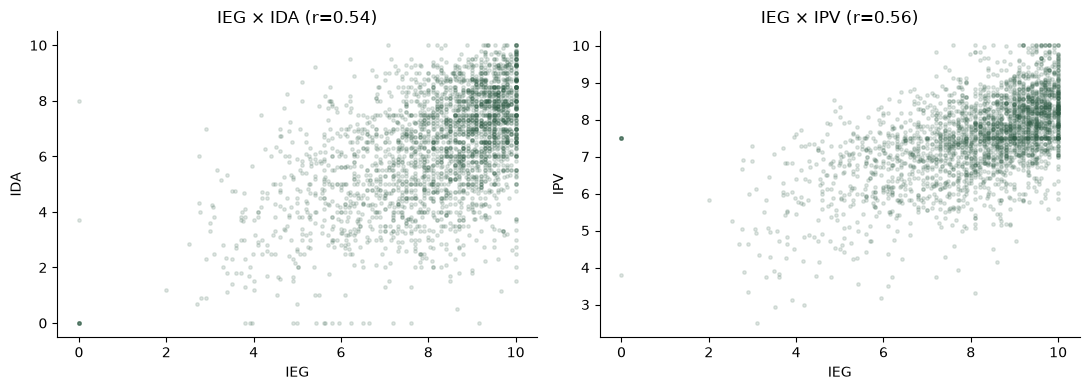

In [3]:
corr_ieg = panel[["ieg", "ida", "ipv"]].corr()
print(corr_ieg.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, r in zip(axes, ["ida", "ipv"], [corr_ieg.loc["ieg", "ida"], corr_ieg.loc["ieg", "ipv"]]):
    ax.scatter(panel["ieg"], panel[col], s=6, alpha=0.15, color="#2f5c46")
    ax.set_xlabel("IEG")
    ax.set_ylabel(col.upper())
    ax.set_title(f"IEG × {col.upper()} (r={r:.2f})")
plt.tight_layout()
plt.show()

**Resposta:** sim, relação direta e moderada nos dois casos — r=0,54 com IDA
e r=0,56 com IPV. Não é forte o bastante pra dizer que engajamento sozinho
explica desempenho ou ponto de virada, mas é consistente: aluno mais engajado
tende a aprender mais e a evoluir mais no IPV, na média.

## Q7 — Quais comportamentos mais influenciam o IPV?

Duas visões: correlação do IPV contínuo com os outros indicadores (todos os
anos), e a diferença de perfil entre quem atingiu o Ponto de Virada e quem
não atingiu (`Atingiu PV`, booleano só populado em 2022 — vazio em 2023/2024
na fonte, mesmo padrão de coluna morta de `Cg`/`Cf`/`Ct` já visto no
notebook 01).

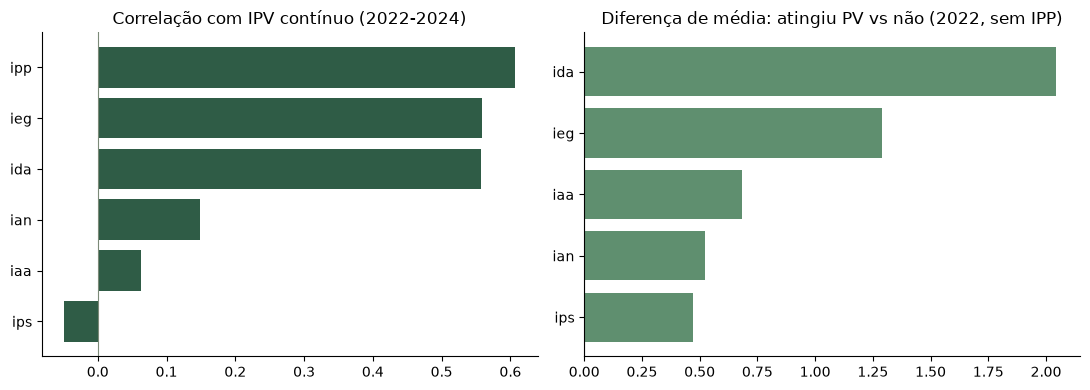

correlação com IPV:
 ipp    0.607
ieg    0.558
ida    0.557
ian    0.149
iaa    0.063
ips   -0.049
Name: ipv, dtype: float64

diferença (Sim - Não), 2022:
 ida    2.045
ieg    1.290
iaa    0.683
ian    0.525
ips    0.472
Name: Sim, dtype: float64


In [4]:
indicadores = ["ida", "ieg", "ips", "ipp", "iaa", "ian"]

corr_ipv = panel[["ipv"] + indicadores].corr()["ipv"].drop("ipv").sort_values(ascending=False)

pv_2022 = panel[panel["ano"] == 2022].dropna(subset=["atingiu_pv"])
gap_pv = pv_2022.groupby("atingiu_pv")[indicadores].mean().diff().iloc[-1].dropna().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(corr_ipv.index[::-1], corr_ipv.values[::-1], color="#2f5c46")
axes[0].set_title("Correlação com IPV contínuo (2022-2024)")
axes[0].axvline(0, color="#7c8a78", linewidth=.8)

axes[1].barh(gap_pv.index[::-1], gap_pv.values[::-1], color="#5f8f6f")
axes[1].set_title("Diferença de média: atingiu PV vs não (2022, sem IPP)")
axes[1].axvline(0, color="#7c8a78", linewidth=.8)
plt.tight_layout()
plt.show()

print("correlação com IPV:\n", corr_ipv.round(3))
print("\ndiferença (Sim - Não), 2022:\n", gap_pv.round(3))

**Resposta:** acadêmico e engajamento dominam, psicossocial não influencia.
Na correlação contínua, IPP (r=0,61), IEG (r=0,56) e IDA (r=0,56) puxam mais
o IPV; IAN e IAA são fracos e IPS é praticamente nulo (r=-0,05). No corte de
2022 (Sim vs Não atingiu PV, sem IPP disponível), quem atinge o ponto de
virada tem IDA 2,0 pontos maior e IEG 1,3 maior — de novo, desempenho e
engajamento são o que mais separa os grupos, não aspectos psicossociais.

## Q8 — Quais combinações de indicadores mais elevam o INDE?

O INDE é uma ponderação fixa de IAN/IDA/IEG/IAA/IPS/IPP/IPV (dicionário de
dados), então correlação individual é quase garantida — o que interessa é
**qual combinação separa mais quem está no topo de quem está na base**.
Comparamos o perfil (z-score) do quartil de INDE mais alto contra o mais
baixo.

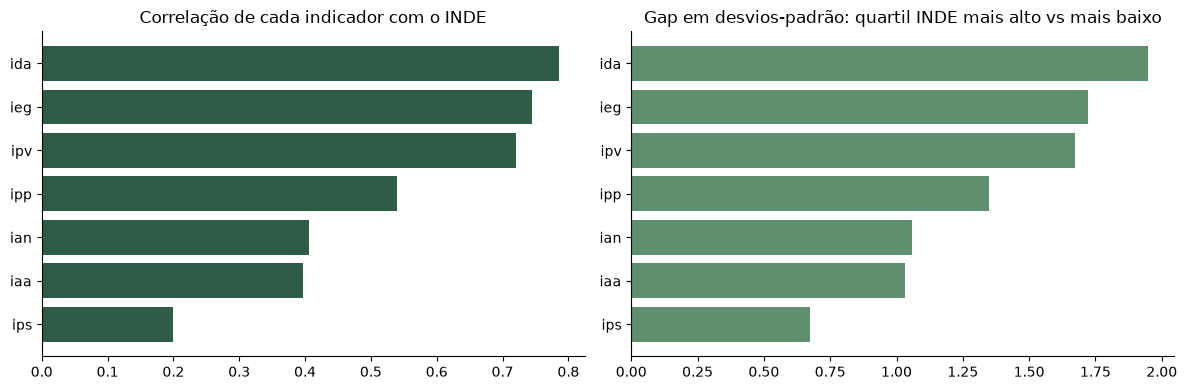

ida    1.95
ieg    1.72
ipv    1.67
ipp    1.35
ian    1.06
iaa    1.03
ips    0.68
dtype: float64


In [5]:
todos = ["ida", "ieg", "ips", "ipp", "iaa", "ian", "ipv"]
corr_inde = panel[["inde"] + todos].corr()["inde"].drop("inde").sort_values(ascending=False)

d = panel.dropna(subset=["inde"] + todos).copy()
d["quartil_inde"] = pd.qcut(d["inde"], 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
z = (d[todos] - d[todos].mean()) / d[todos].std()
z["quartil_inde"] = d["quartil_inde"].values
perfil_z = z.groupby("quartil_inde", observed=True).mean()
gap_q4_q1 = (perfil_z.loc["Q4 (maior)"] - perfil_z.loc["Q1 (menor)"]).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(corr_inde.index[::-1], corr_inde.values[::-1], color="#2f5c46")
axes[0].set_title("Correlação de cada indicador com o INDE")

axes[1].barh(gap_q4_q1.index[::-1], gap_q4_q1.values[::-1], color="#5f8f6f")
axes[1].set_title("Gap em desvios-padrão: quartil INDE mais alto vs mais baixo")
axes[1].axvline(0, color="#7c8a78", linewidth=.8)
plt.tight_layout()
plt.show()

print(gap_q4_q1.round(2))

**Resposta:** IDA e IEG puxam mais o INDE pra cima — quem está no quartil
mais alto de INDE tem, em média, 1,95 desvio-padrão a mais de IDA e 1,72 a
mais de IEG que quem está no quartil mais baixo, seguidos por IPV (1,67) e
IPP (1,35). IAN, IAA e principalmente IPS diferenciam muito menos (0,7-1,1
desvio). Ou seja: a combinação que mais eleva o INDE é desempenho acadêmico
+ engajamento — reforça o mesmo padrão da Q7 (IPV) e da investigação do IPS
em `03_eda_psicossocial.ipynb`.

## Q10 — Os indicadores mostram melhora consistente ao longo do ciclo?

Teste mais rigoroso: olhar só quem passou pelos 3 anos no programa (468
alunos, `docs/decisions/0001-consolidacao-painel.md`) — assim a composição
da coorte não muda de ano pra ano e dá pra ver evolução real, não só média
da safra.

468 alunos presentes nos 3 anos


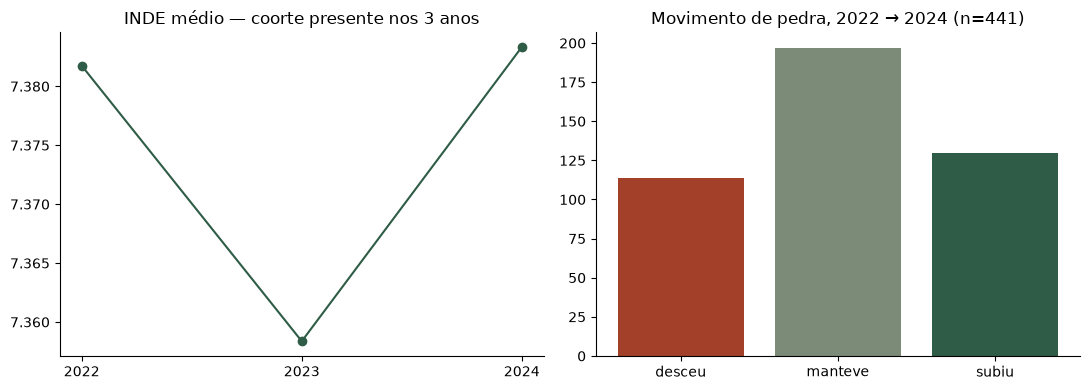

ano
2022    7.381748
2023    7.358370
2024    7.383332
Name: inde, dtype: float64

desceu     114
manteve    197
subiu      130
dtype: int64 
% subiu: 29.5


In [6]:
tres_anos = panel[panel.groupby("ra")["ano"].transform("nunique") == 3]
print(f"{tres_anos['ra'].nunique()} alunos presentes nos 3 anos")

inde_ano = tres_anos.groupby("ano")["inde"].mean()

p22 = tres_anos[tres_anos.ano == 2022].set_index("ra")["pedra_norm"]
p24 = tres_anos[tres_anos.ano == 2024].set_index("ra")["pedra_norm"]
comuns = p22.index.intersection(p24.index)
rank = {p: i for i, p in enumerate(PEDRA_ORDEM)}
delta_pedra = p24.loc[comuns].map(rank) - p22.loc[comuns].map(rank)
delta_pedra = delta_pedra.dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(inde_ano.index, inde_ano.values, marker="o", color="#2f5c46")
axes[0].set_title("INDE médio — coorte presente nos 3 anos")
axes[0].set_xticks(inde_ano.index)

movimento = pd.Series({
    "desceu": (delta_pedra < 0).sum(),
    "manteve": (delta_pedra == 0).sum(),
    "subiu": (delta_pedra > 0).sum(),
})
axes[1].bar(movimento.index, movimento.values, color=["#a2402a", "#7c8a78", "#2f5c46"])
axes[1].set_title("Movimento de pedra, 2022 → 2024 (n=441)")
plt.tight_layout()
plt.show()

print(inde_ano)
print()
print(movimento, "\n% subiu:", round(100 * movimento["subiu"] / movimento.sum(), 1))

**Resposta:** não confirma melhora consistente. O INDE médio da coorte que
ficou os 3 anos no programa é praticamente reto: 7,38 → 7,36 → 7,38. A
movimentação de pedra entre 2022 e 2024 é quase simétrica (~29% sobe, ~26%
desce, o resto mantém) — tem gente melhorando, mas tem gente piorando na
mesma proporção, e no agregado isso não gera uma tendência de melhora
estatisticamente visível ao longo do ciclo.